In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov




/tmp/ipykernel_2335358/667692420.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [4]:
df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4000_warmup_3000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_probe_all_deproj_cib_1p7_dBeta_2000_4000_num_chains_32.pkl','rb'))
# df.keys()
sig8 = df['sigma8']
# nchains = 80
nchains = 64
sig8_rs = sig8.reshape(nchains,-1)
# print(sig8_rs.shape)
from numpyro.diagnostics import autocorrelation, autocovariance

acorr = autocorrelation(sig8_rs, axis=1)
ind_del = []
for ji in range(acorr.shape[0]):
    if np.std(acorr[ji,100:]) > 0.075:
        ind_del.append(ji)

print(len(ind_del), ind_del)



31 [3, 6, 9, 11, 14, 17, 18, 19, 20, 22, 23, 26, 27, 28, 30, 31, 33, 36, 37, 40, 42, 43, 44, 45, 46, 49, 50, 52, 54, 56, 60]


In [5]:
samps = []
keys = []
for key in df:
    # if ('base' not in key) and ('decentered' not in key):
        # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
        if key not in ['RUN_SETTINGS', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')



samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
if len(ind_del) > 0:
    samps_sel = np.delete(samps_sel, ind_del, axis=0)
else:
    samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
print(samps.shape, samps_sel.shape)


(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(256000,)
(132000, 44) (33, 4000, 44)


In [6]:
# samps.shape
nsamp_tot = samps.shape[0]
indsel = np.sort(np.random.randint(0, nsamp_tot, 100))
indsel



array([   895,   3583,   4625,   5108,   6473,   6965,   7534,   8724,
         9263,   9600,  11043,  11373,  11574,  11616,  12937,  13672,
        14263,  14704,  15074,  16990,  18481,  18545,  19605,  19889,
        21371,  22861,  22937,  23522,  24526,  26279,  28335,  32081,
        34419,  34812,  35251,  36113,  36393,  36476,  37976,  38208,
        38727,  38983,  40275,  40544,  41104,  43836,  44348,  46489,
        46561,  50390,  54209,  55418,  56334,  57185,  61675,  62137,
        62368,  64312,  64412,  68898,  71682,  76175,  76661,  78549,
        82418,  83357,  83623,  86506,  87264,  89474,  90175,  92047,
        92900,  93113,  96862,  97422,  97892,  98846, 102104, 105312,
       105945, 106560, 107965, 108235, 108430, 110736, 112736, 114417,
       115355, 115912, 116240, 117255, 121624, 121880, 122589, 122851,
       124644, 125120, 126967, 126969])

In [8]:
import warnings
warnings.filterwarnings("ignore")


In [9]:
from tqdm import tqdm

# ind_post = keys.index('potential_energy')
# post = -1.* samps[:,ind_post]

# map_ind = np.where(post == post.max())[0][0]

Y_model_all_samp = []

for map_ind in tqdm(indsel):
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        # print(key, samps[map_ind, jk])
        saved_bestfit[key] = samps[map_ind, jk]
    
    # potential_energy -4916.635080802822
    import yaml
    import pathlib
    curr_path = pathlib.Path().absolute()
    abs_path_data = os.path.abspath(curr_path / "../../data/") 
    abs_path_src = os.path.abspath(curr_path / "../../src/") 
    abs_path_results = os.path.abspath(curr_path / "../../results/") 
    abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
    
    from deepmerge import always_merger
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    
    # saved_bestift
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict = {}
    nz_info_dict['z_array_source'] = z_array
    nz_info_dict['nbins'] = 4
    for ji in range(nz_info_dict['nbins']):
        nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']
    
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    
    
    h = sim_params_dict['cosmo']['H0'] / 100.0
    Ob = sim_params_dict['cosmo']['Ob0']
    Om = sim_params_dict['cosmo']['Om0']
    import astropy.units as u
    from astropy import constants as const
    import jax_cosmo.background as bkgrd
    sigmat = const.sigma_T
    m_e = const.m_e
    c = const.c
    coeff = sigmat / (m_e * (c ** 2))
    oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
    const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value
    
    from scipy.interpolate import interp1d
    import jax_cosmo.background as bkgrd
    z_array = profiles_test.z_array
    scale_fac_a_array = 1.0 / (1.0 + z_array)
    indz = 0
    Ez = np.sqrt(bkgrd.growth_factor(profiles_test.cosmo_jax, scale_fac_a_array))[indz]
    # M200_noh = M_array[indM]/h
    h70 = h/0.7
    M_array = profiles_test.M_array
    Y_model_all = np.zeros(len(M_array))
    Y_ss_all = np.zeros(len(M_array))
    for jM in range(len(M_array)):
        Mj = M_array[jM]
        M200_noh = Mj/h
        Y_ss = 97.6 * (1/h70) * (Ez**(2/3.)) * (M200_noh/(1e15/h70))**(5/3.) * (Ob/0.043) * (0.25/Om)
    
        # r200_jM = BCMP_test.r200c_mat[jM, indz]
        r200_jM = profiles_test.r200c_mat[jM, indz]    
        r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
        Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
        interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
        Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
        Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))
    
        Y_model_all[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
        Y_ss_all[jM] = Y_ss
        
    Y_model_all_samp.append(Y_model_all)



100%|██████████| 100/100 [11:50<00:00,  7.11s/it]


In [10]:
# pl.figure()
# for ji in range(len(indsel)):
#     pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
# # pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
# pl.plot(M_array, 1.8e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
# pl.xscale('log')
# pl.yscale('log')
# pl.xlabel(r'$M_{200c}$', fontsize=20)
# pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
# pl.xlim(1e13, 1.2e15)
# pl.ylim(1e-3, 2e1)
# pl.legend(fontsize=18)
# pl.tick_params(axis='both', which='major', labelsize=16)
# pl.tick_params(axis='both', which='minor', labelsize=16)
# # pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
# pl.show()



In [11]:
# np.save('Y_model_all.npz',Y_model_all_samp)
Y_model_all_samp = np.array(Y_model_all_samp)



In [12]:
# Y_model_all_samp.shape
Ymin = np.percentile(Y_model_all_samp, 16, axis=0)
Ymax = np.percentile(Y_model_all_samp, 84, axis=0)


In [13]:
# Ymin


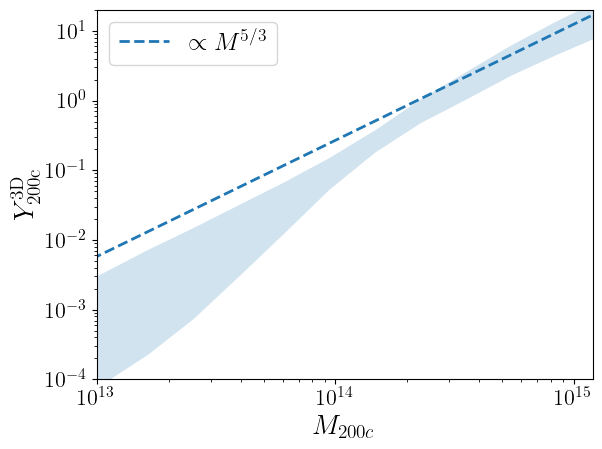

In [15]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
pl.fill_between(M_array, Ymin, Ymax, alpha=0.2)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
pl.plot(M_array, 1.25e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
pl.ylim(1e-4, 2e1)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()



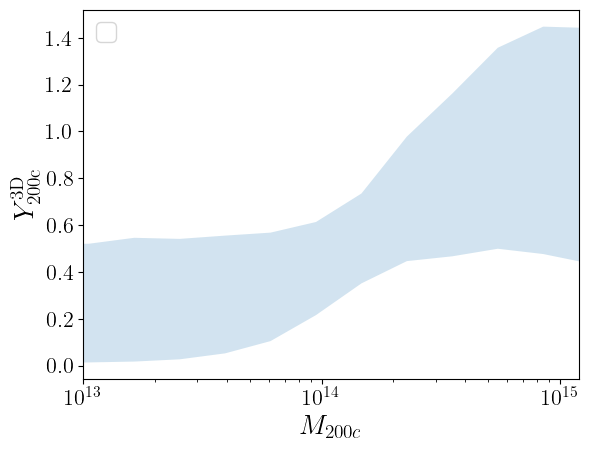

In [18]:
pl.figure()
# for ji in range(len(indsel)):
    # pl.plot(M_array, 1.8*Y_model_all_samp[ji],  lw=2.0)
pl.fill_between(M_array, Ymin/(1.25e-24 * (M_array**(5/3.))), Ymax/(1.25e-24 * (M_array**(5/3.))), alpha=0.2)
# pl.plot(M_array, Y_ss_all, label='SS', lw=2.0)
# pl.plot(M_array, 1.25e-24 * (M_array**(5/3.)), label=r'$\propto M^{5/3}$', lw=2.0, ls='--')
pl.xscale('log')
# pl.yscale('log')
pl.xlabel(r'$M_{200c}$', fontsize=20)
pl.ylabel(r'$Y^{\rm 3D}_{\rm 200c}$', fontsize=20)
pl.xlim(1e13, 1.2e15)
# pl.ylim(1e-4, 2e1)
pl.legend(fontsize=18)
pl.tick_params(axis='both', which='major', labelsize=16)
pl.tick_params(axis='both', which='minor', labelsize=16)
# pl.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/Y_M_bestfit.png', bbox_inches='tight', dpi=300)
pl.show()

